In [ ]:
from google.colab import files
uploaded = files.upload()
# Select both menu.csv and retail_sales_dataset.csv

Saving archive (2).zip to archive (2).zip
Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile
import os

# Unzip the uploaded files
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('.')
            print(f"Extracted {filename}")

# Verify that the CSV files are now present
print(os.listdir('.'))


Extracted archive (2).zip
Extracted archive (1).zip
['.config', 'archive (1).zip', 'menu.csv', 'archive (2).zip', 'retail_sales_dataset.csv', 'sample_data']


In [ ]:
import pandas as pd

menu = pd.read_csv('menu.csv')
sales = pd.read_csv('retail_sales_dataset.csv')

print("=== Menu Dataset ===")
print(menu.head())
print(menu.shape)

print("\n=== Sales Dataset ===")
print(sales.head())
print(sales.shape)

=== Menu Dataset ===
    Category                              Item    Serving Size  Calories  \
0  Breakfast                      Egg McMuffin  4.8 oz (136 g)       300   
1  Breakfast                 Egg White Delight  4.8 oz (135 g)       250   
2  Breakfast                  Sausage McMuffin  3.9 oz (111 g)       370   
3  Breakfast         Sausage McMuffin with Egg  5.7 oz (161 g)       450   
4  Breakfast  Sausage McMuffin with Egg Whites  5.7 oz (161 g)       400   

   Calories from Fat  Total Fat  Total Fat (% Daily Value)  Saturated Fat  \
0                120       13.0                         20            5.0   
1                 70        8.0                         12            3.0   
2                200       23.0                         35            8.0   
3                250       28.0                         43           10.0   
4                210       23.0                         35            8.0   

   Saturated Fat (% Daily Value)  Trans Fat  ...  Carbohydr

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import re

# Combine all text from Item names and Categories
text_data = menu['Item'].tolist() + menu['Category'].tolist()
text_data += sales['Product Category'].tolist()

# Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

cleaned = [clean_text(t) for t in text_data]
print("Sample cleaned text:", cleaned[:10])

Sample cleaned text: ['egg mcmuffin', 'egg white delight', 'sausage mcmuffin', 'sausage mcmuffin with egg', 'sausage mcmuffin with egg whites', 'steak  egg mcmuffin', 'bacon egg  cheese biscuit regular biscuit', 'bacon egg  cheese biscuit large biscuit', 'bacon egg  cheese biscuit with egg whites regular biscuit', 'bacon egg  cheese biscuit with egg whites large biscuit']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from collections import defaultdict

# Build word frequency from item names
all_words = []
for item in cleaned:
    all_words.extend(item.split())

from collections import Counter
word_freq = Counter(all_words)

# Autocomplete function
def autocomplete(prefix, top_n=5):
    suggestions = [w for w in word_freq if w.startswith(prefix.lower())]
    suggestions = sorted(suggestions, key=lambda x: word_freq[x], reverse=True)
    return suggestions[:top_n]

# Test it
print(autocomplete("sa"))   # suggests 'sausage', 'salad' etc
print(autocomplete("ch"))   # suggests 'chicken', 'chocolate' etc

['sausage', 'sandwich', 'salad', 'salads']
['chicken', 'cheese', 'chocolate', 'child', 'chip']


In [ ]:
from textblob import TextBlob

def autocorrect(word):
    corrected = TextBlob(word).correct()
    return str(corrected)

# Test it
print(autocorrect("mcchikn"))    # → chicken
print(autocorrect("brakfast"))   # → breakfast
print(autocorrect("retial"))     # → retail

mcchikn
breakfast
retail


In [ ]:
# Test autocomplete accuracy
test_prefixes = ['sa', 'ch', 'be', 'eg', 'cl']
print("=== Autocomplete Results ===")
for p in test_prefixes:
    print(f"Prefix '{p}': {autocomplete(p)}")

# Test autocorrect accuracy
test_words = ['brakfast', 'chiken', 'salede', 'retial', 'electrnics']
correct_words = ['breakfast', 'chicken', 'salad', 'retail', 'electronics']

correct = 0
for wrong, right in zip(test_words, correct_words):
    result = autocorrect(wrong)
    match = result == right
    if match:
        correct += 1
    print(f"{wrong} → {result} ({'✓' if match else '✗'})")

print(f"\nAccuracy: {correct}/{len(test_words)} = {correct/len(test_words)*100}%")

=== Autocomplete Results ===
Prefix 'sa': ['sausage', 'sandwich', 'salad', 'salads']
Prefix 'ch': ['chicken', 'cheese', 'chocolate', 'child', 'chip']
Prefix 'be': ['beauty', 'beverages', 'beef']
Prefix 'eg': ['egg']
Prefix 'cl': ['clothing', 'classic', 'clubhouse', 'club']
brakfast → breakfast (✓)
chiken → chicken (✓)
salede → saved (✗)
retial → retail (✓)
electrnics → electronics (✓)

Accuracy: 4/5 = 80.0%


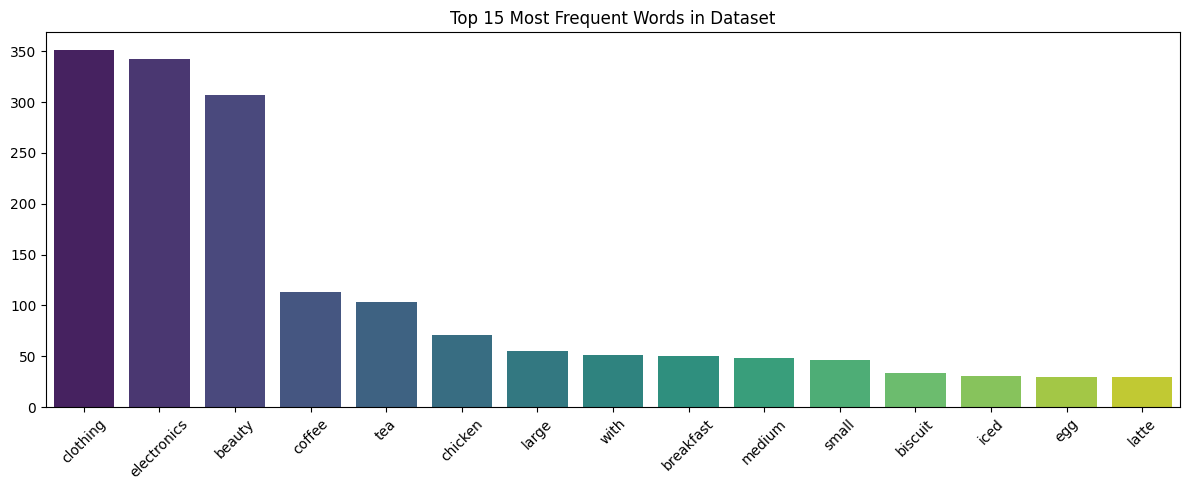

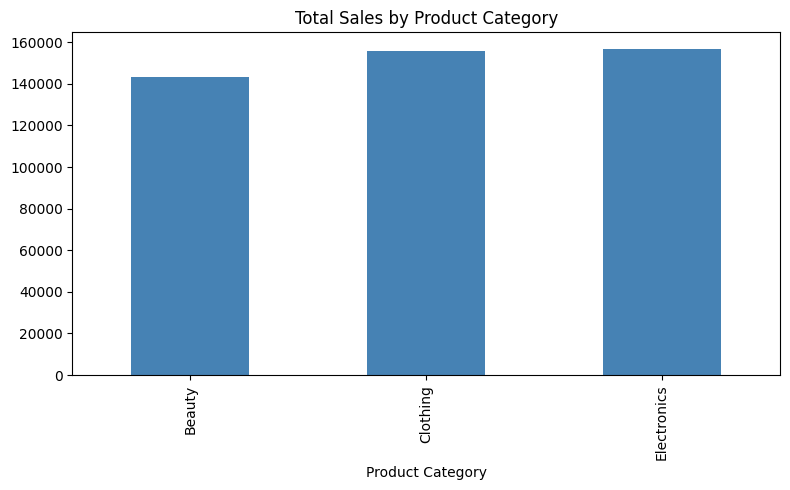

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 15 most frequent words
top_words = word_freq.most_common(15)
words, counts = zip(*top_words)

plt.figure(figsize=(12,5))
sns.barplot(x=list(words), y=list(counts), palette='viridis', hue=list(words), legend=False)
plt.title('Top 15 Most Frequent Words in Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sales by category
plt.figure(figsize=(8,5))
sales.groupby('Product Category')['Total Amount'].sum().plot(kind='bar', color='steelblue')
plt.title('Total Sales by Product Category')
plt.tight_layout()
plt.show()